In [1]:
using Plots, IntervalArithmetic, Serialization, LaTeXStrings, Arblib, SpecialFunctions

In [2]:
setprecision(8192)
function enlarge(x::Interval{BigFloat})
    isguaranteed(x) || error("interval is not guaranteed")
    return interval(BigFloat(inf(x), RoundDown), BigFloat(sup(x), RoundUp))
end

SpecialFunctions.besseli(ν::Interval{BigFloat},z::Interval{BigFloat}) = interval(besseli(Arb(ν), Arb(z)))
SpecialFunctions.besseli(ν::Rational,z::Interval{BigFloat}) = interval(besseli(interval(BigFloat, ν), z))

function compute_b1(κ)
    κ̂ = κ^2/interval(8)
    num = κ^2*(besseli(-1//4, κ̂)+besseli(3//4, κ̂)+besseli(5//4, κ̂))+(interval(4)+κ^2)*besseli(1//4, κ̂)
    denom = interval(2)*κ*(besseli(-1//4, κ̂)+besseli(1//4, κ̂))
    return num/denom
end

compute_b1 (generic function with 1 method)

In [3]:
κ = interval(4)
g(x, y, κ, n) = (x + y - κ)/sqrt(n)/interval(2)

g (generic function with 1 method)

In [4]:
f(x) = -x + sqrt(interval(1) + x^2)

f (generic function with 1 method)

In [5]:
c⁺ = I"1.025"
c⁻ = I"0.987"

[0.987, 0.987001]_com

In [6]:
B⁻(n) = sqrt(n/interval(3))*c⁻

B⁻ (generic function with 1 method)

In [7]:
B⁺(n) = sqrt(n/interval(3))*c⁺

B⁺ (generic function with 1 method)

In [8]:
N₂ = 9000000
while true
    b1 = sqrt(interval(12)+(-sqrt(interval(3)/interval(N₂))*κ+c⁺*(sqrt(interval(1)-interval(1)/interval(N₂))+sqrt(interval(1)+interval(1)/interval(N₂))))^2)-interval(2)*c⁺-interval(2)*c⁻
    b2 = interval(2)*c⁺-(sqrt(interval(12)+(interval(2)*c⁻)^2)+sqrt(interval(3)/interval(N₂))*κ-c⁻*(sqrt(interval(1)-interval(1)/interval(N₂))+sqrt(interval(1)+interval(1)/interval(N₂))))
    if inf(b1)>0 && inf(b2)>0
        break
    else
        N₂ *=2
    end
end
    

In [9]:
b⁻ = B⁻.(interval.(collect(1:N₂)))
b⁺ = B⁺.(interval.(collect(1:N₂)));

In [10]:
Sb⁻ = f.(g.(vcat(interval(0.0),b⁻[1:N₂-1]), vcat(b⁻[2:N₂], B⁻(interval(N₂+1))), κ, interval.(collect(1:N₂)))).*sqrt.(interval.(1:N₂))
Sb⁺ = f.(g.(vcat(interval(0.0),b⁺[1:N₂-1]), vcat(b⁺[2:N₂], B⁺(interval(N₂+1))), κ, interval.(collect(1:N₂)))).*sqrt.(interval.(1:N₂));

In [11]:
N₃ = argmax(cumsum((inf.(b⁺-Sb⁻).<=0) .||(inf.(Sb⁺-b⁻).<=0)))

9215

In [12]:
setprecision(8192*8)
b₁ = compute_b1(interval(BigFloat, κ))
b₀ = interval(BigFloat, 0.0)
b = zeros(Interval{BigFloat},40001)
b[1:2] = [b₀, b₁]
for n = 2:40000
    b[n+1] = κ+(interval(BigFloat, n-1)/b[n])-b[n]-b[n-1]
end
b = b[2:end];

In [13]:
N₁ = sum((inf.(b⁺[1:N₃]-b[1:N₃]).<=0) .|| (inf.(b[1:N₃]-b⁻[1:N₃]).<=0))
if all(((inf.(b⁺[1:N₃]-b[1:N₃]).>0) .&& (inf.(b[1:N₃]-b⁻[1:N₃]).>0))[N₁+1:end])
    println("N₁ = "*string(N₁)*" checked")
end

N₁ = 2186 checked


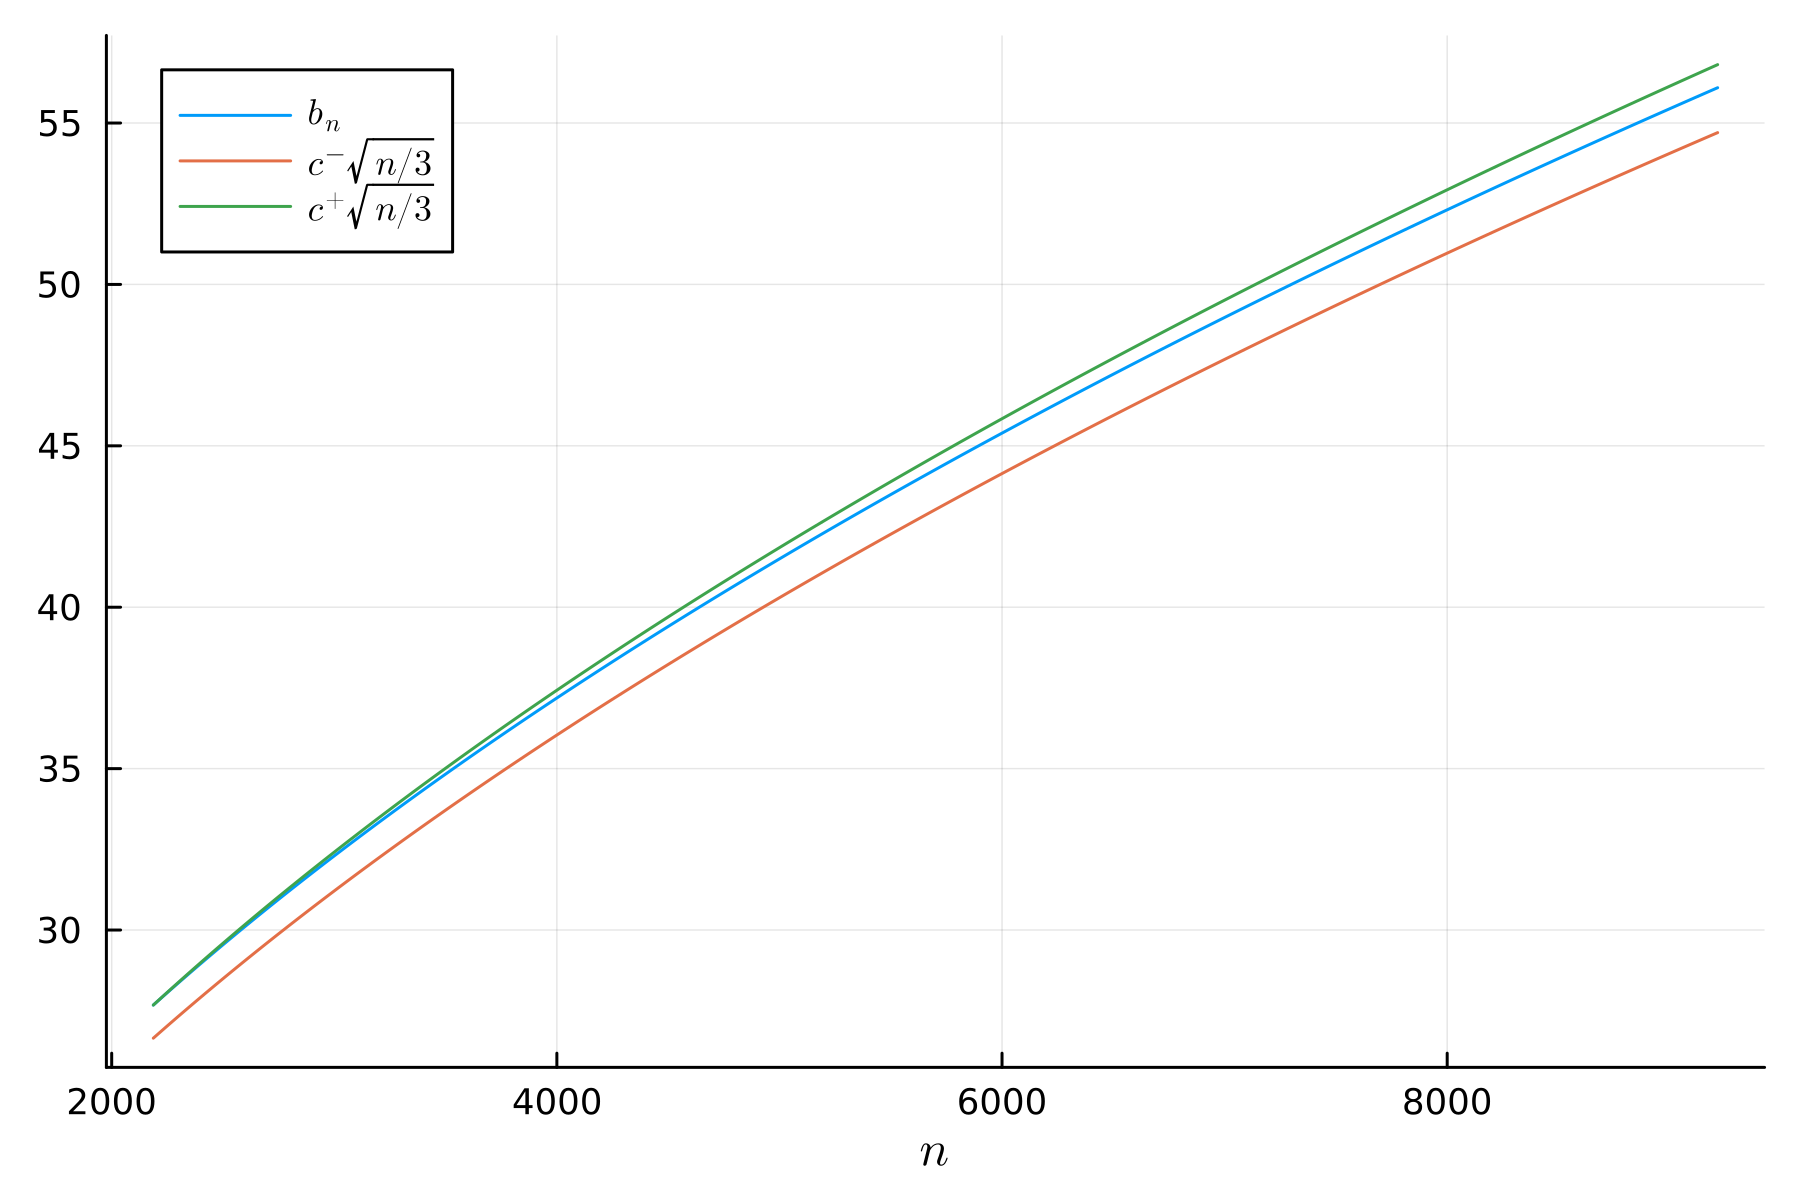

In [14]:
plot(N₁+1:N₃,Float64.(mid.(b[N₁+1:N₃])), label = L"b_n", dpi = 300)
plot!(N₁+1:N₃,sup.(b⁻[N₁+1:N₃]), label = L"c^-\sqrt{n/3}", xlabel= L"n", xformatter=:plain)
plot!(N₁+1:N₃,inf.(b⁺[N₁+1:N₃]), label = L"c^+\sqrt{n/3}")

In [15]:
png("actual_bounds")

"actual_bounds.png"

In [16]:
N₄ = argmax(cumsum((inf.(b⁺-Sb⁻).<=0) .||(inf.(Sb⁺-b⁻).<=0)))
while sum((inf.(b⁺-Sb⁻).<=0) .||(inf.(Sb⁺-b⁻).<=0)) >0
    for i in N₄:-1:1
        while inf(b⁺[i]-Sb⁻[i]) <= 0.0
            b⁺[i] *= I"1.01"
        end
    end
    Sb⁺ = f.(g.(vcat(interval(0.0),b⁺[1:N₂-1]), vcat(b⁺[2:N₂], B⁺(interval(N₂+1))), κ, interval.(collect(1:N₂)))).*sqrt.(interval.(1:N₂));
    N₄ = argmax(cumsum((inf.(b⁺-Sb⁻).<=0) .||(inf.(Sb⁺-b⁻).<=0)))
    for i in N₄:-1:1
        while inf(Sb⁺[i]-b⁻[i]) <= 0.0
            b⁻[i] *= I"0.999"
        end
    end
    Sb⁻ = f.(g.(vcat(interval(0.0),b⁻[1:N₂-1]), vcat(b⁻[2:N₂], B⁻(interval(N₂+1))), κ, interval.(collect(1:N₂)))).*sqrt.(interval.(1:N₂))
    N₄ = argmax(cumsum((inf.(b⁺-Sb⁻).<=0) .||(inf.(Sb⁺-b⁻).<=0)))
end

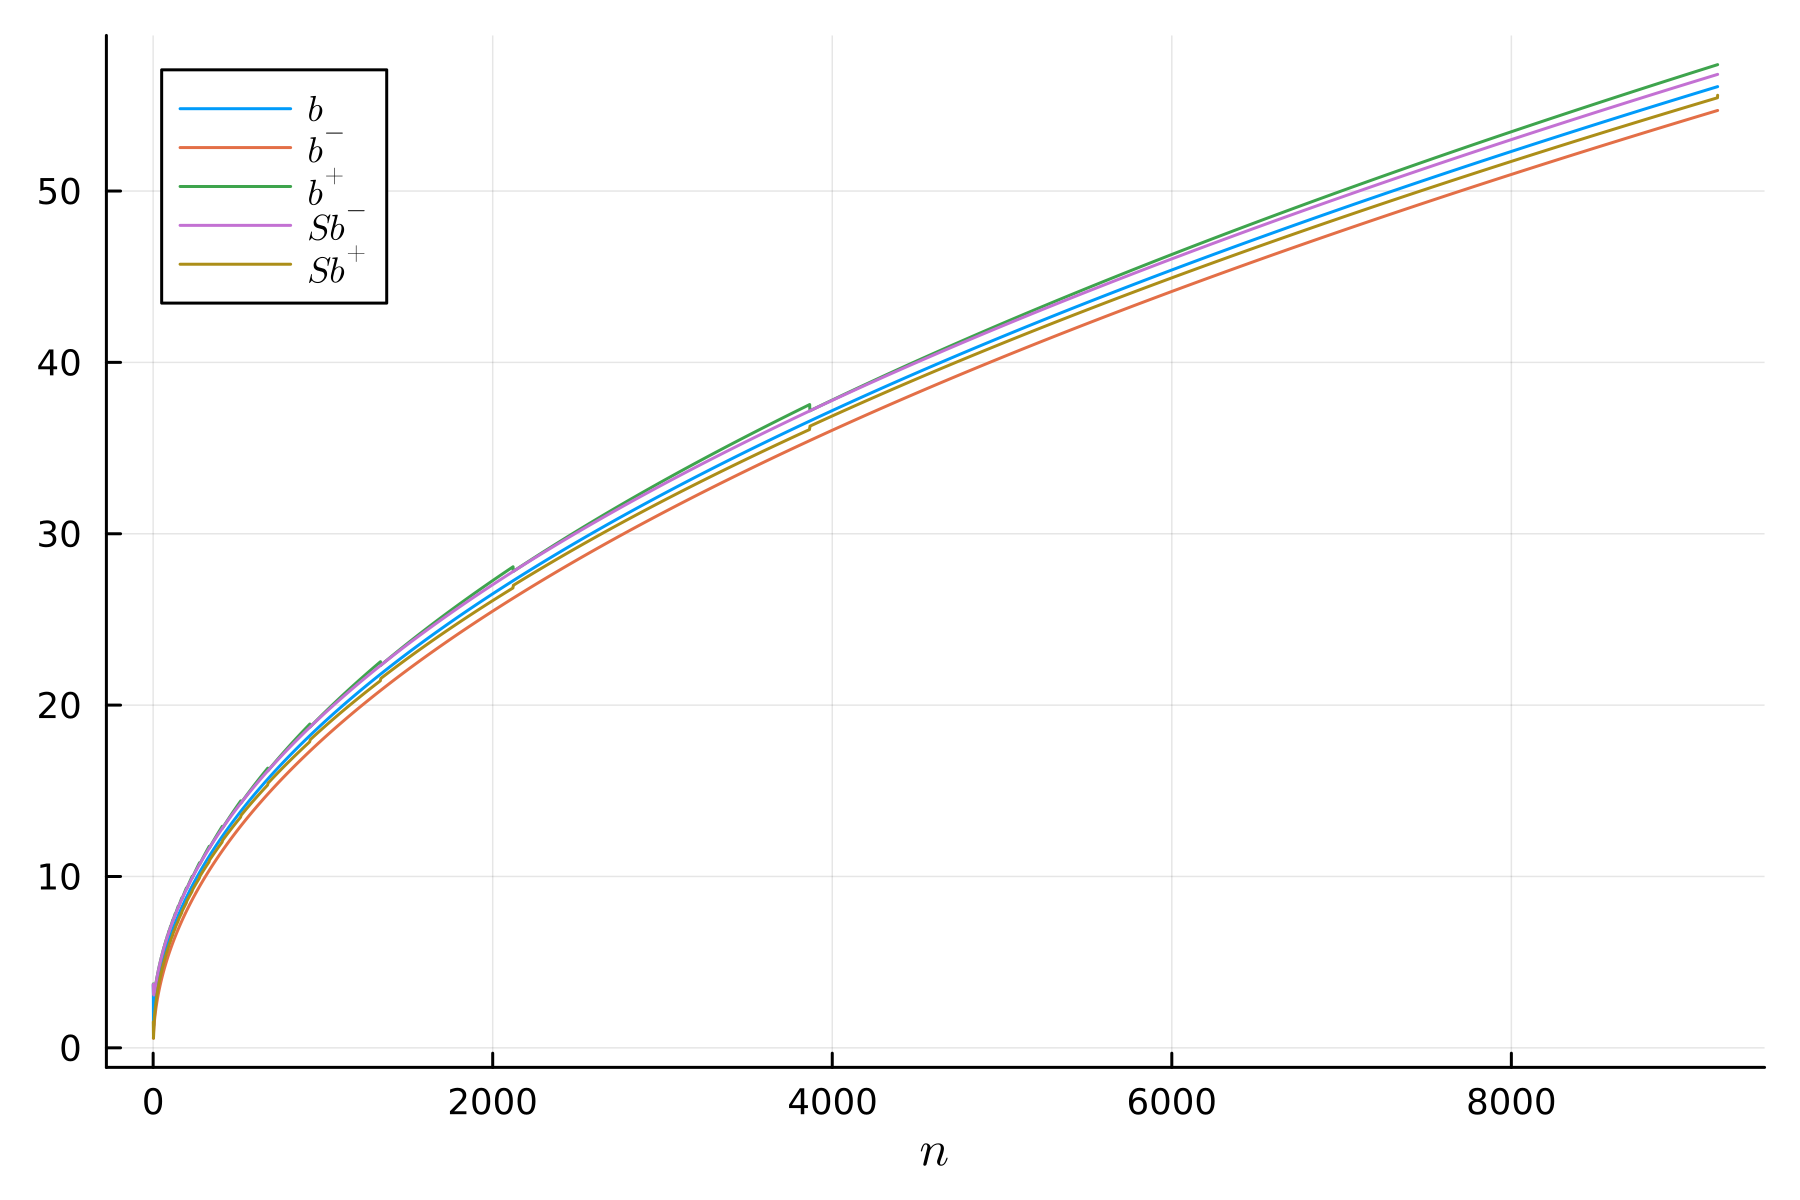

In [17]:
m = 1
M = N₃
# M = 10000
plot(m:M, mid.(b[m:M]), label = L"b")
plot!(m:M, sup.(b⁻)[m:M], label = L"b^-", xlabel= L"n", xformatter=:plain, dpi = 300)
plot!(m:M, inf.(b⁺)[m:M], label = L"b^+")
plot!(m:M, sup.(Sb⁻)[m:M], label = L"Sb^-")
plot!(m:M, inf.(Sb⁺)[m:M], label = L"Sb^+")

In [18]:
png("inflation_construction")

"inflation_construction.png"

In [19]:
N₀ = 50
# decrease c⁻ until bound is satisfied
while true
    if any(inf.(b[N₀:N₁+5]) .< sup.(B⁻.(interval.(collect(N₀:N₁+5)))))
        c⁻ *= I"0.999"
    else
        break
    end
end

# increase c⁺ until bound is satisfied
while true
    if any(inf.(B⁺.(interval.(collect(N₀:N₁+5)))) .< sup.(b[N₀:N₁+5]))
        c⁺ *= I"1.001"
    else
        break
    end
end

In [20]:
c⁺

[1.17659, 1.1766]_com